In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder 

In [44]:
# Load clicks dataset
clicks = pd.read_csv("yoochoose-clicks.csv")

# Load buys dataset
buys = pd.read_csv("yoochoose-buys.csv")

In [45]:
# Display first 5 rows
print("Clicks Dataset:")
display(clicks.head())

Clicks Dataset:


,SessionID,Timestamp,ItemID,Category
0,1,2014-04-07T10:51:09.277Z,214536502,0
1,1,2014-04-07T10:54:09.868Z,214536500,0
2,1,2014-04-07T10:54:46.998Z,214536506,0
3,1,2014-04-07T10:57:00.306Z,214577561,0
4,2,2014-04-07T13:56:37.614Z,214662742,0


In [46]:
print("\nBuys Dataset:")
display(buys.head())


Buys Dataset:


,SessionID,Timestamp,ItemID,Price,Quantity
0,420374,2014-04-06T18:44:58.314Z,214537888,12462,1
1,420374,2014-04-06T18:44:58.325Z,214537850,10471,1
2,281626,2014-04-06T09:40:13.032Z,214535653,1883,1
3,420368,2014-04-04T06:13:28.848Z,214530572,6073,1
4,420368,2014-04-04T06:13:28.858Z,214835025,2617,1


In [47]:
#sort by id and timestamp

clicks = clicks.sort_values(
    by=["SessionID", "Timestamp"]
).reset_index(drop=True)

clicks.head()

,SessionID,Timestamp,ItemID,Category
0,1,2014-04-07T10:51:09.277Z,214536502,0
1,1,2014-04-07T10:54:09.868Z,214536500,0
2,1,2014-04-07T10:54:46.998Z,214536506,0
3,1,2014-04-07T10:57:00.306Z,214577561,0
4,2,2014-04-07T13:56:37.614Z,214662742,0


In [48]:
#create session sequence

session_sequences = (
    clicks.groupby("SessionID")["ItemID"]
    .apply(list)
    .reset_index(name="ItemSequence")
)

In [49]:
print(session_sequences.head())

print("\nNumber of sessions:", len(session_sequences))

   SessionID                                       ItemSequence
0          1       [214536502, 214536500, 214536506, 214577561]
1          2  [214662742, 214662742, 214825110, 214757390, 2...
2          3                  [214716935, 214774687, 214832672]
3          4                             [214836765, 214706482]
4          6                             [214701242, 214826623]

Number of sessions: 266910


In [50]:
print("Number of sessions:", len(session_sequences))

print("Total clicks:",
      session_sequences["ItemSequence"].apply(len).sum())

Number of sessions: 266910
Total clicks: 1048575


In [51]:
import numpy as np

# Get all unique item IDs
all_items = np.concatenate(session_sequences["ItemSequence"].values)
unique_items = np.unique(all_items)

# Create mapping: original item ID -> encoded ID
item2id = {item: idx + 1 for idx, item in enumerate(unique_items)}

# Encode each session
session_sequences["EncodedSequence"] = session_sequences["ItemSequence"].apply(
    lambda seq: [item2id[item] for item in seq]
)

print(session_sequences.head())

   SessionID                                       ItemSequence  \
0          1       [214536502, 214536500, 214536506, 214577561]   
1          2  [214662742, 214662742, 214825110, 214757390, 2...   
2          3                  [214716935, 214774687, 214832672]   
3          4                             [214836765, 214706482]   
4          6                             [214701242, 214826623]   

                           EncodedSequence  
0                 [1251, 1250, 1252, 4963]  
1  [9947, 9947, 17967, 16798, 16800, 2701]  
2                    [15777, 17206, 18918]  
3                           [19645, 14154]  
4                           [13686, 18072]  


In [52]:
# Sessions that made at least one purchase
buy_sessions = set(buys["SessionID"].unique())

print("Total Purchase Sessions:", len(buy_sessions))

Total Purchase Sessions: 467402


In [53]:
# Label = 1 if session exists in buys dataset, else 0
session_sequences["Label"] = session_sequences["SessionID"].apply(
    lambda x: 1 if x in buy_sessions else 0
)

In [54]:
print(session_sequences.head())

   SessionID                                       ItemSequence  \
0          1       [214536502, 214536500, 214536506, 214577561]   
1          2  [214662742, 214662742, 214825110, 214757390, 2...   
2          3                  [214716935, 214774687, 214832672]   
3          4                             [214836765, 214706482]   
4          6                             [214701242, 214826623]   

                           EncodedSequence  Label  
0                 [1251, 1250, 1252, 4963]      0  
1  [9947, 9947, 17967, 16798, 16800, 2701]      0  
2                    [15777, 17206, 18918]      0  
3                           [19645, 14154]      0  
4                           [13686, 18072]      0  


In [55]:
print(session_sequences["Label"].value_counts())

print(session_sequences["Label"].value_counts(normalize=True) * 100)

Label
0    249336
1     17574
Name: count, dtype: int64
Label
0    93.415758
1     6.584242
Name: proportion, dtype: float64


In [56]:
session_sequences.to_csv("session_sequences.csv", index=False)

In [57]:
from sklearn.preprocessing import LabelEncoder

# Create encoder
item_encoder = LabelEncoder()

# Fit on all unique ItemIDs
item_encoder.fit(clicks["ItemID"])

# Encode ItemIDs in clicks dataset
clicks["EncodedItemID"] = item_encoder.transform(clicks["ItemID"]) + 1

In [58]:
print(clicks[["ItemID", "EncodedItemID"]].head())

print("Total Unique Items:", len(item_encoder.classes_))

      ItemID  EncodedItemID
0  214536502           1251
1  214536500           1250
2  214536506           1252
3  214577561           4963
4  214662742           9947
Total Unique Items: 21128


In [59]:
# Create sequences using encoded Item IDs
session_sequences = (
    clicks.groupby("SessionID")["EncodedItemID"]
    .apply(list)
    .reset_index(name="ItemSequence")
)

# Add purchase labels
buy_sessions = set(buys["SessionID"].unique())

session_sequences["Label"] = session_sequences["SessionID"].apply(
    lambda x: 1 if x in buy_sessions else 0
)

print(session_sequences.head())

   SessionID                             ItemSequence  Label
0          1                 [1251, 1250, 1252, 4963]      0
1          2  [9947, 9947, 17967, 16798, 16800, 2701]      0
2          3                    [15777, 17206, 18918]      0
3          4                           [19645, 14154]      0
4          6                           [13686, 18072]      0


In [60]:
# Length of each session
session_sequences["SequenceLength"] = session_sequences["ItemSequence"].apply(len)

print(session_sequences["SequenceLength"].describe())

count    266910.000000
mean          3.928571
std           4.043820
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max         200.000000
Name: SequenceLength, dtype: float64


In [61]:
print("Maximum Sequence Length:", session_sequences["SequenceLength"].max())

Maximum Sequence Length: 200


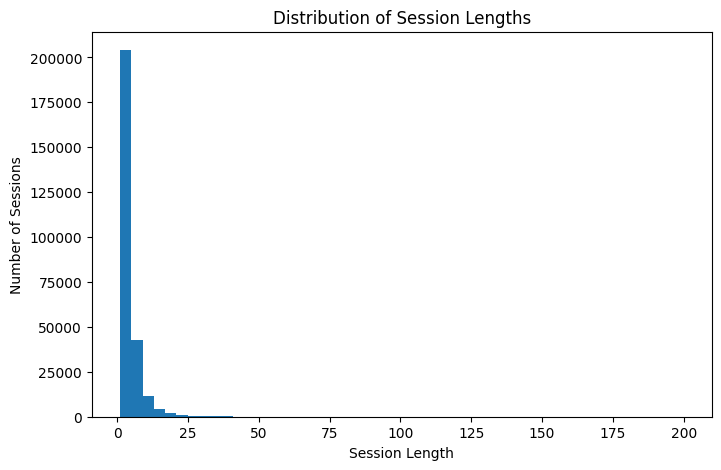

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(session_sequences["SequenceLength"], bins=50)
plt.xlabel("Session Length")
plt.ylabel("Number of Sessions")
plt.title("Distribution of Session Lengths")
plt.show()

In [63]:
print("Maximum Sequence Length:", session_sequences["SequenceLength"].max())

Maximum Sequence Length: 200


In [64]:
print(session_sequences["SequenceLength"].describe())
print(session_sequences["SequenceLength"].quantile([0.90, 0.95, 0.99]))

count    266910.000000
mean          3.928571
std           4.043820
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max         200.000000
Name: SequenceLength, dtype: float64
0.90     7.0
0.95    10.0
0.99    20.0
Name: SequenceLength, dtype: float64


In [65]:
# Create sequences using encoded Item IDs
session_sequences = (
    clicks.groupby("SessionID")["EncodedItemID"]
    .apply(list)
    .reset_index(name="ItemSequence")
)

# Add purchase labels
buy_sessions = set(buys["SessionID"].unique())

session_sequences["Label"] = session_sequences["SessionID"].apply(
    lambda x: 1 if x in buy_sessions else 0
)

print(session_sequences.head())

   SessionID                             ItemSequence  Label
0          1                 [1251, 1250, 1252, 4963]      0
1          2  [9947, 9947, 17967, 16798, 16800, 2701]      0
2          3                    [15777, 17206, 18918]      0
3          4                           [19645, 14154]      0
4          6                           [13686, 18072]      0


In [66]:
# Length of each session
session_sequences["SequenceLength"] = session_sequences["ItemSequence"].apply(len)

print(session_sequences["SequenceLength"].describe())

count    266910.000000
mean          3.928571
std           4.043820
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max         200.000000
Name: SequenceLength, dtype: float64


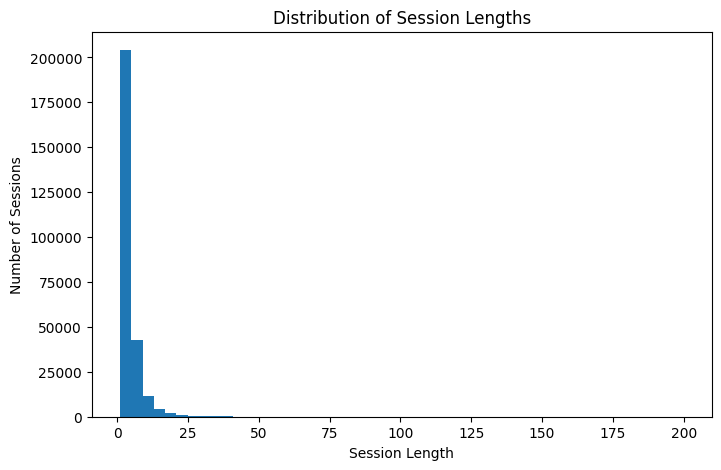

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(session_sequences["SequenceLength"], bins=50)
plt.xlabel("Session Length")
plt.ylabel("Number of Sessions")
plt.title("Distribution of Session Lengths")
plt.show()

In [68]:
print(session_sequences["SequenceLength"].quantile([0.90, 0.95, 0.99]))# Save processed session dataset
session_sequences.to_pickle("session_sequences.pkl")

0.90     7.0
0.95    10.0
0.99    20.0
Name: SequenceLength, dtype: float64


In [69]:
# Save processed session dataset
session_sequences.to_pickle("session_sequences.pkl")

In [70]:
# Save item encoder
import joblib
joblib.dump(item_encoder, "item_encoder.pkl")

['item_encoder.pkl']

In [71]:
import os

print(os.getcwd())          # Current working directory
print(os.listdir())         # Files in the current directory

C:\Users\DHANANJAY\mini project 3
['.ipynb_checkpoints', 'best_gru_purchase_intent.pth', 'item_encoder.pkl', 'model.ipynb', 'session_sequences.csv', 'session_sequences.pkl', 'yoochoose-buys.csv', 'yoochoose-clicks.csv', 'youchoose_preprocess.ipynb']


In [72]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

model.eval()

predictions = []
actuals = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(X_batch).squeeze()

        probs = torch.sigmoid(outputs)

        preds = (probs >= 0.5).float()

        predictions.extend(preds.cpu().numpy())
        actuals.extend(y_batch.cpu().numpy())

print("Accuracy :", accuracy_score(actuals, predictions))
print("Precision:", precision_score(actuals, predictions))
print("Recall   :", recall_score(actuals, predictions))
print("F1 Score :", f1_score(actuals, predictions))
print("ROC AUC  :", roc_auc_score(actuals, predictions))

print("\nConfusion Matrix")
print(confusion_matrix(actuals, predictions))

print("\nClassification Report")
print(classification_report(actuals, predictions))

NameError: name 'model' is not defined